In [ ]:
import pandas as pd 
from datasets import load_dataset

ds = load_dataset("7Xan7der7/us_airline_sentiment")


In [2]:
print(ds)
df = pd.DataFrame(ds['train'])
print(df)

df.head()

DatasetDict({
    train: Dataset({
        features: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'name', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone'],
        num_rows: 14640
    })
})
           tweet_id airline_sentiment  airline_sentiment_confidence  \
0      5.703060e+17           neutral                        1.0000   
1      5.703010e+17          positive                        0.3486   
2      5.703010e+17           neutral                        0.6837   
3      5.703010e+17          negative                        1.0000   
4      5.703010e+17          negative                        1.0000   
...             ...               ...                           ...   
14635  5.695880e+17          positive                        0.3487   
14636  5.695870e+17          negative                        1.0000   
14637  5.695870e+17           neutral            

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.703060e+17,neutral,1.0000,None,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,None,2/24/2015 11:35,None,Eastern Time (US & Canada)
1,5.703010e+17,positive,0.3486,None,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,None,2/24/2015 11:15,None,Pacific Time (US & Canada)
2,5.703010e+17,neutral,0.6837,None,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,None,2/24/2015 11:15,Lets Play,Central Time (US & Canada)
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,None,2/24/2015 11:15,None,Pacific Time (US & Canada)
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,None,2/24/2015 11:14,None,Pacific Time (US & Canada)


In [ ]:
negative_df = df[df['airline_sentiment'] == 'negative']
print(negative_df.groupby('airline').size())

negative_rate = (negative_df.groupby('airline').size() / df.groupby('airline').size())
print(negative_rate)

In [25]:
df['airline_sentiment'].value_counts(normalize=True) 

airline_sentiment
negative    0.626913
neutral     0.211680
positive    0.161407
Name: proportion, dtype: float64

In [ ]:
df['has_url'] = df['text'].str.contains(r'https\S+|www\S?')

<Axes: xlabel='airline,airline_sentiment'>

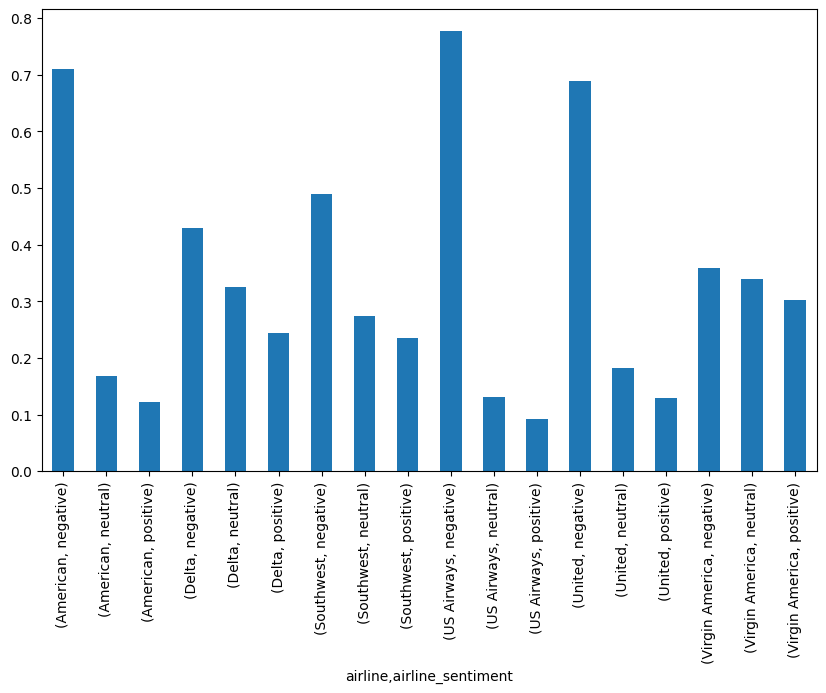

In [13]:
dd = df.groupby('airline')['airline_sentiment'].value_counts(normalize=1)
dd.sort_values()
dd.plot(kind='bar', figsize=(10, 6))

In [25]:
df["has_url"] = df["text"].str.contains(r'http\S+|www.\S')

sentiment_with_urls = df[df["has_url"]].groupby('airline')["airline_sentiment"].value_counts(normalize=0)
sentiment_without_urls = df[~df["has_url"]]["airline_sentiment"].value_counts(normalize=True)

print(sentiment_with_urls)

airline         airline_sentiment
American        negative              68
                neutral               42
                positive              22
Delta           neutral              235
                negative              78
                positive              68
Southwest       neutral               83
                positive              67
                negative              53
US Airways      negative              94
                neutral               30
                positive              10
United          negative             143
                neutral               59
                positive              41
Virgin America  neutral               48
                positive              24
                negative              12
Name: count, dtype: int64


In [ ]:
df['has_mention'] = df["text"].str.contains('@').sum



<bound method Series.sum of 0        True
1        True
2        True
3        True
4        True
         ... 
14635    True
14636    True
14637    True
14638    True
14639    True
Name: text, Length: 14640, dtype: bool>

In [33]:
df[df['tweet_coord'] != 'None'].head()
filtered_df = df[df['tweet_coord'].notna()]
filtered_df.tail()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,has_url
14577,5.695970e+17,negative,0.6694,Customer Service Issue,0.3451,American,angiedrich,0,@AmericanAir I have never on all my trips on a...,"[33.93939612, -118.38973148]",2/22/2015 12:36,"Santa Monica, CA",Pacific Time (US & Canada),False
14596,5.695930e+17,negative,1.0000,Customer Service Issue,1.0000,American,catiekate,0,@AmericanAir we've been on hold for hours.,"[35.22534456, -106.57241352]",2/22/2015 12:23,None,None,False
14612,5.695920e+17,negative,1.0000,Cancelled Flight,0.6333,American,tcunningham10,0,@AmericanAir a friend is having flight Cancell...,"[40.46692522, -82.64567078]",2/22/2015 12:16,Central Ohio,Eastern Time (US & Canada),False
14624,5.695900e+17,negative,1.0000,Can't Tell,1.0000,American,yourlama,0,"@AmericanAir Call me Chairman, or call me Emer...","[32.9070889, -97.03785947]",2/22/2015 12:10,None,None,False
14625,5.695900e+17,positive,1.0000,None,NaN,American,DrCaseyJRudkin,0,@AmericanAir Flight 236 was great. Fantastic c...,"[40.64946781, -73.76624703]",2/22/2015 12:08,East Coast,None,True
